# Process pose estimation data into xarr

In [26]:
import sys
from pathlib import Path
import importlib
import scripts.process_pose_data  # import the module itself, not just its contents

sys.path.append(str(Path().resolve().parent))

import scripts.process_pose_data as pp
importlib.reload(pp)

<module 'scripts.process_pose_data' from '/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis/scripts/process_pose_data.py'>

In [2]:
predictions_path = Path("/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/predictions/")
cameras = ["CameraEast", "CameraNorth", "CameraSouth", "CameraWest", "CameraNest", "CameraTop"]

# Run once to ingest
out_dir = pp.ingest_pose_data(
    cameras=cameras,
    pred_path=predictions_path,
    fps=50.0,                        # optional, defaults to 50
)

2026-04-27 11:46:48.195 | WARNING  | movement.io.load_poses:_ds_from_sleap_labels_file:583 - Could not find SLEAP Track in /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/predictions/CameraEast_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_145131.predictions.slp. Assuming single-individual dataset and assigning default individual name.


Ingesting CameraEast: CameraEast_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_145131.predictions.slp


2026-04-27 11:46:48.999 | WARNING  | movement.io.load_poses:_ds_from_sleap_labels_file:583 - Could not find SLEAP Track in /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/predictions/CameraNorth_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_154023.predictions.slp. Assuming single-individual dataset and assigning default individual name.


  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraEast_pose_data.nc
Ingesting CameraNorth: CameraNorth_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_154023.predictions.slp
  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraNorth_pose_data.nc
Ingesting CameraSouth: CameraSouth_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_132201.predictions.slp


2026-04-27 11:46:49.115 | WARNING  | movement.io.load_poses:_ds_from_sleap_labels_file:583 - Could not find SLEAP Track in /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/predictions/CameraSouth_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_132201.predictions.slp. Assuming single-individual dataset and assigning default individual name.
2026-04-27 11:46:49.245 | WARNING  | movement.io.load_poses:_ds_from_sleap_labels_file:583 - Could not find SLEAP Track in /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/predictions/CameraWest_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_141446.predictions.slp. Assuming single-individual dataset and assigning default individual name.
2026-04-27 11:46:49.265 | WARNING  | movement.io.load_poses:_ds_from_sleap_labels_file:583 - Could not find SLEAP Track in /Users/zosiasus/Documents/Ae

  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraSouth_pose_data.nc
Ingesting CameraWest: CameraWest_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_141446.predictions.slp
  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraWest_pose_data.nc
Ingesting CameraNest: CameraNest_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_152523.predictions.slp
  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraNest_pose_data.nc
Ingesting CameraTop: CameraTop_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_160641.predictions.slp


2026-04-27 11:46:49.545 | WARNING  | movement.io.load_poses:_ds_from_sleap_labels_file:583 - Could not find SLEAP Track in /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/predictions/CameraTop_2026-04-14T14-00-00.avi_abcEphysPilot01_unseen_labels.v001.slp.260416_160641.predictions.slp. Assuming single-individual dataset and assigning default individual name.


  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraTop_pose_data.nc


In [3]:
print(out_dir)

/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed


# Find and extract stable points in pose data

In [27]:
import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

sys.path.append(str(Path().resolve().parent))

import scripts.extract_stable_events as ese
importlib.reload(ese)

<module 'scripts.extract_stable_events' from '/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis/scripts/extract_stable_events.py'>

In [28]:
processed_path = out_dir
cam = "CameraEast"

ds = xr.open_dataset(processed_path / f"{cam}_pose_data.nc")
print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 27320, space: 2, keypoints: 4, individuals: 1)
Coordinates:
  * time         (time) float64 219kB 0.0 0.02 0.04 0.06 ... 546.3 546.4 546.4
  * space        (space) <U1 8B 'x' 'y'
  * keypoints    (keypoints) <U8 128B 'corner_1' 'corner_2' ... 'corner_4'
  * individuals  (individuals) <U4 16B 'id_0'
Data variables:
    position     (time, space, keypoints, individuals) float32 874kB ...
    confidence   (time, keypoints, individuals) float32 437kB ...
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              50.0
    time_unit:        seconds
    source_file:      /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEph...



Processing: CameraEast
  Confidence distribution (valid n=32592):
    Q1=0.7869  Q2=0.9461  Q3=1.0048  max=1.2253
  Inferred confidence threshold (Q1): 0.7869
  Valid frames (all corners + confidence): 4504/27320
  Median card area (valid frames): 2511.9 px²
  Geometry-passing frames: 4504/4504
  Inferred pixel tolerance (P10 of displacements): 1.325 px
  Stable windows found: 36


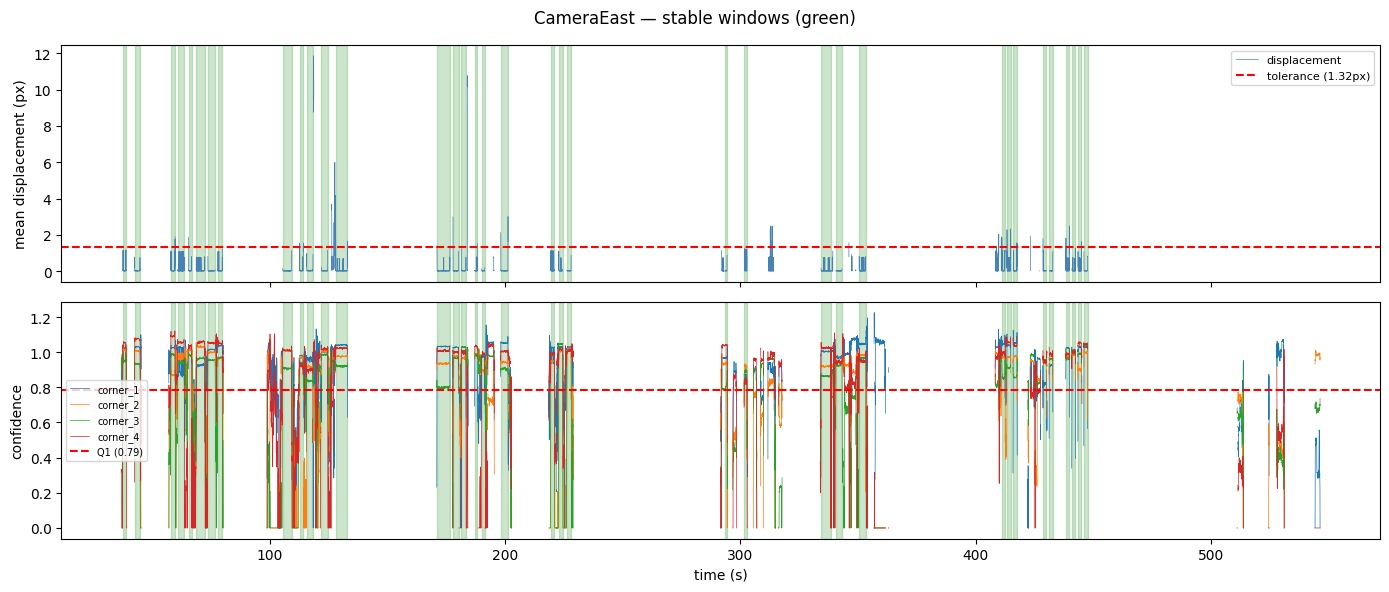

  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraEast_stable_events.nc

Processing: CameraNorth
  Confidence distribution (valid n=33088):
    Q1=0.7769  Q2=0.9294  Q3=0.9760  max=1.1475
  Inferred confidence threshold (Q1): 0.7769
  Valid frames (all corners + confidence): 4560/26549
  Median card area (valid frames): 2380.9 px²
  Geometry-passing frames: 4560/4560
  Inferred pixel tolerance (P10 of displacements): 1.176 px
  Stable windows found: 38


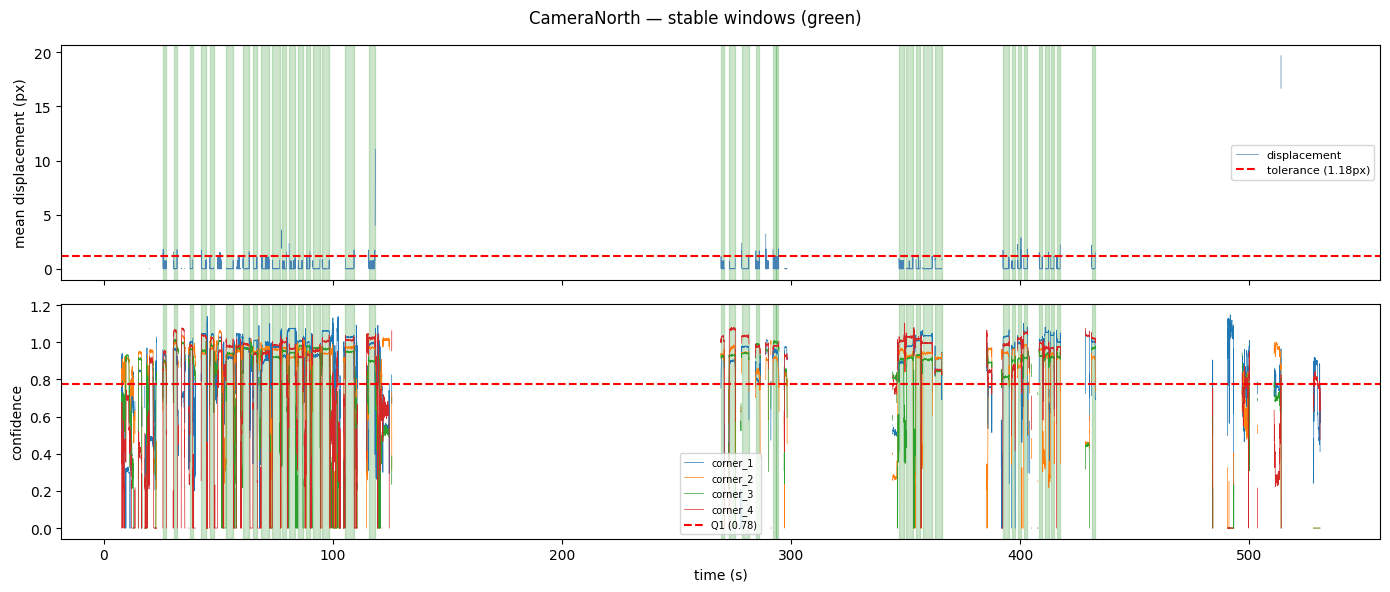

  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraNorth_stable_events.nc

Processing: CameraSouth
  Confidence distribution (valid n=27188):
    Q1=0.7663  Q2=0.8651  Q3=0.9265  max=1.1171
  Inferred confidence threshold (Q1): 0.7663
  Valid frames (all corners + confidence): 3566/28028
  Median card area (valid frames): 2996.3 px²
  Geometry-passing frames: 3566/3566
  Inferred pixel tolerance (P10 of displacements): 1.113 px
  Stable windows found: 28


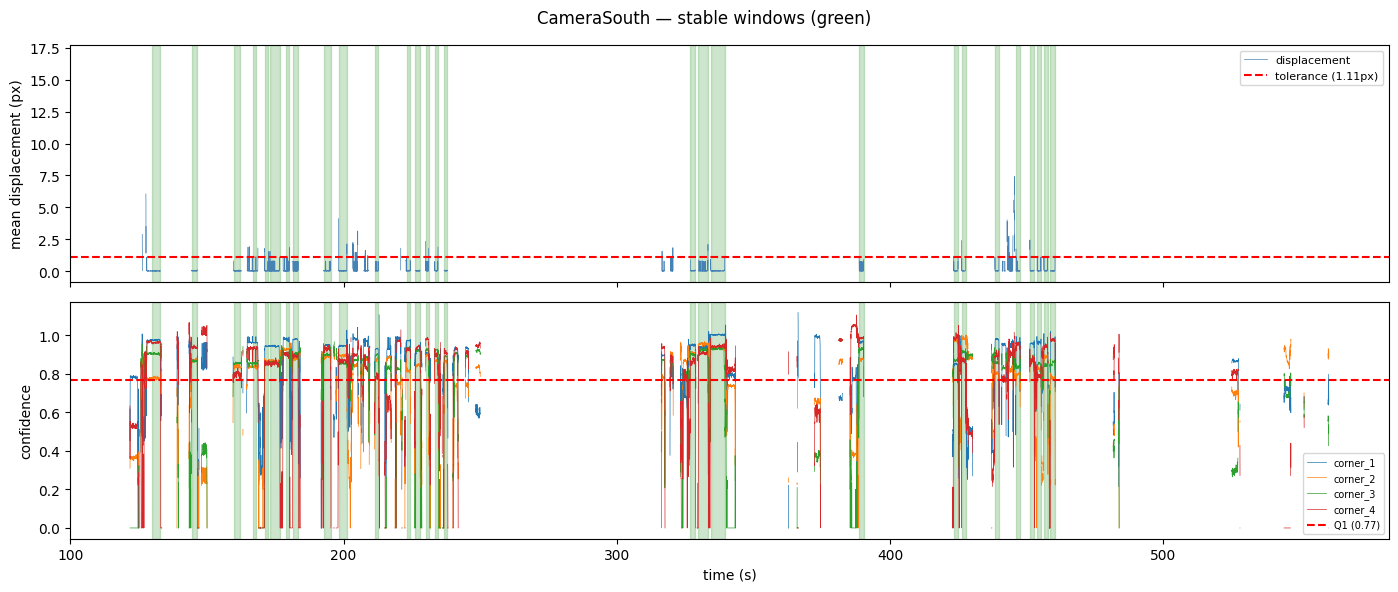

  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraSouth_stable_events.nc

Processing: CameraWest
  Confidence distribution (valid n=32032):
    Q1=0.7969  Q2=0.9367  Q3=0.9860  max=1.1747
  Inferred confidence threshold (Q1): 0.7969
  Valid frames (all corners + confidence): 4141/27949
  Median card area (valid frames): 2449.2 px²
  Geometry-passing frames: 4141/4141
  Inferred pixel tolerance (P10 of displacements): 3.039 px
  Stable windows found: 40


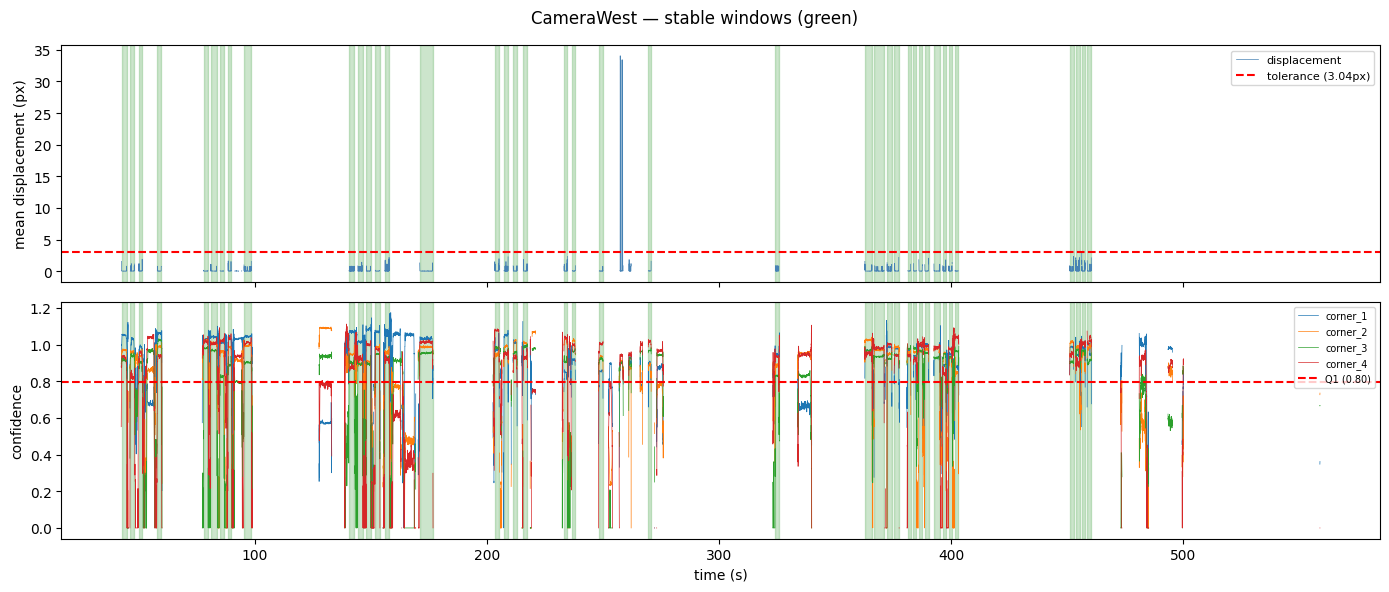

  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraWest_stable_events.nc

Processing: CameraNest
  Confidence distribution (valid n=676):
    Q1=0.2777  Q2=0.4615  Q3=0.7297  max=0.9624
  Inferred confidence threshold (Q1): 0.2777
  Valid frames (all corners + confidence): 36/14331
  Median card area (valid frames): 11996.5 px²
  Geometry-passing frames: 36/36
  Inferred pixel tolerance (P10 of displacements): 0.967 px
  Stable windows found: 0


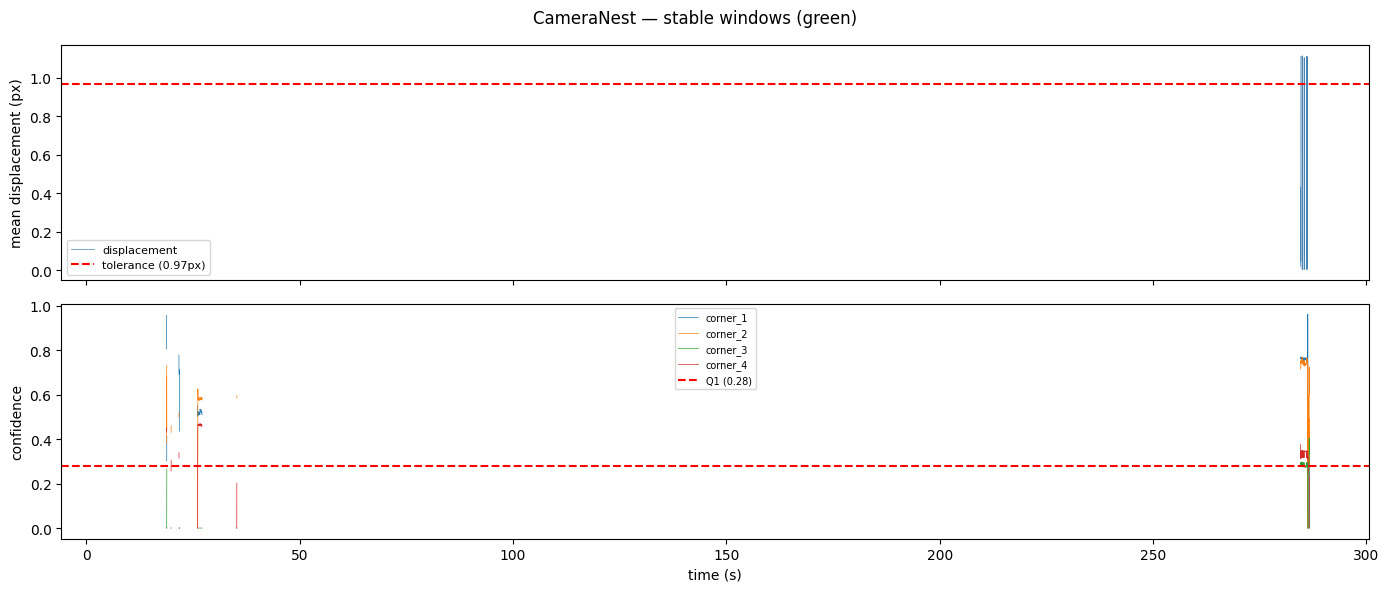

  [WARNING] No stable events found for CameraNest, skipping save.

Processing: CameraTop
  Confidence distribution (valid n=72672):
    Q1=0.7354  Q2=0.9283  Q3=1.0197  max=1.2529
  Inferred confidence threshold (Q1): 0.7354
  Valid frames (all corners + confidence): 7515/28048
  Median card area (valid frames): 812.1 px²
  Geometry-passing frames: 7514/7515
  Inferred pixel tolerance (P10 of displacements): 1.195 px
  Stable windows found: 61


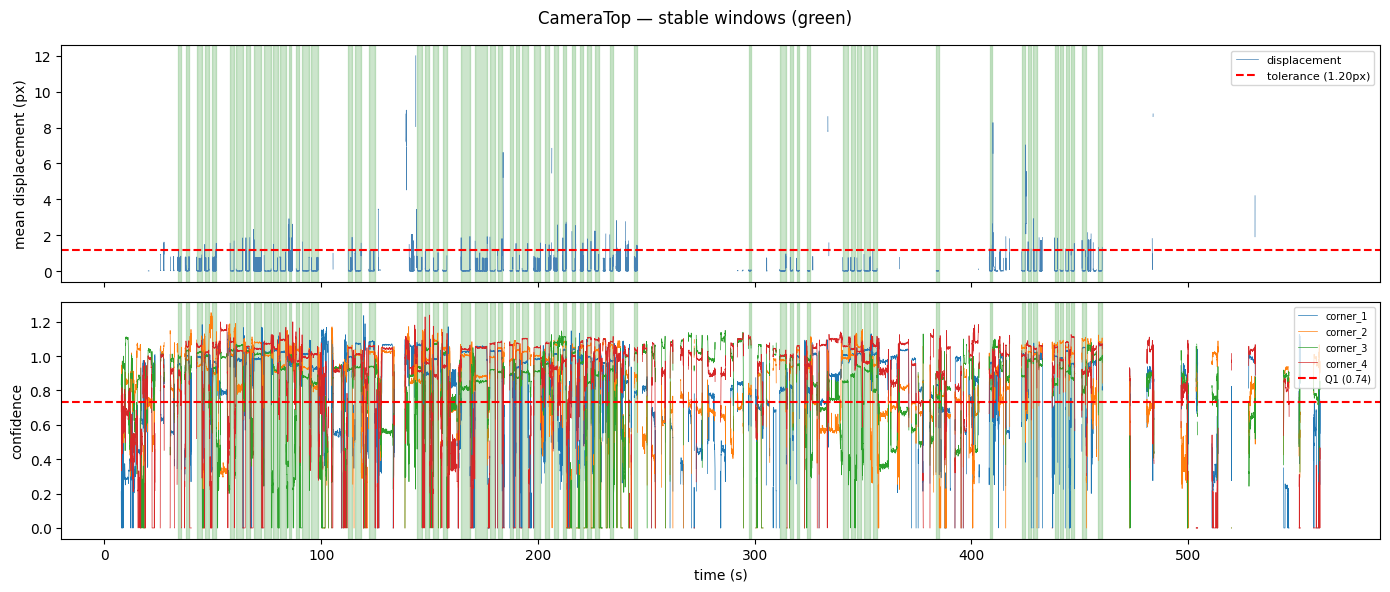

  Saved: /Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/abcEphysPilot01_sleap_for_card/models/card_inference_results/processed/CameraTop_stable_events.nc


In [30]:
for cam in cameras:
    out_dir = ese.extract_stable_events(
        cameras=[cam], 
        processed_path=processed_path,
        min_duration_s=1.0,
        pixel_tolerance=None,
        min_confidence=None,
        min_area_fraction=0.5,
        fps=50.0,
        visual=True,
    )

In [32]:
# for cam in cameras:
#     ds_by_cam = ese.load_stable_events([cam], out_dir)
#     print(ds_by_cam[cam])

# Match pairs in time for remapping

In [34]:
sys.path.append(str(Path().resolve().parent))

import scripts.match_stable_correspondences as msc
importlib.reload(msc)

<module 'scripts.match_stable_correspondences' from '/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis/scripts/match_stable_correspondences.py'>

In [35]:
correspondence_df = msc.match_stable_correspondences(
    cameras=cameras,
    processed_path=processed_path,
    min_overlap_s=0.5,
)

  [WARNING] No stable events file for CameraNest, skipping.

Loaded stable events for: ['CameraEast', 'CameraNorth', 'CameraSouth', 'CameraWest', 'CameraTop']
  CameraEast: 36 events
  CameraNorth: 38 events
  CameraSouth: 28 events
  CameraWest: 40 events
  CameraTop: 61 events
  CameraEast ↔ CameraNorth: 15 overlapping event pairs
  CameraEast ↔ CameraSouth: 11 overlapping event pairs
  CameraEast ↔ CameraWest: 4 overlapping event pairs
  CameraEast ↔ CameraTop: 27 overlapping event pairs
  CameraNorth ↔ CameraSouth: 0 overlapping event pairs
  CameraNorth ↔ CameraWest: 13 overlapping event pairs
  CameraNorth ↔ CameraTop: 18 overlapping event pairs
  CameraSouth ↔ CameraWest: 11 overlapping event pairs
  CameraSouth ↔ CameraTop: 18 overlapping event pairs
  CameraWest ↔ CameraTop: 23 overlapping event pairs

Unique card placements found: 72

Coverage summary:
  Total placements : 72
  Cameras seen per placement: mean=2.4  min=2  max=4

  CameraEast           seen in 35/72 placements

In [39]:
correspondence_df.head()

,placement_id,time_start,time_end,n_cameras_seen,CameraEast_corner_1_x,CameraEast_corner_1_y,CameraEast_corner_2_x,CameraEast_corner_2_y,CameraEast_corner_3_x,CameraEast_corner_3_y,...,CameraTop_corner_1_y,CameraTop_corner_2_x,CameraTop_corner_2_y,CameraTop_corner_3_x,CameraTop_corner_3_y,CameraTop_corner_4_x,CameraTop_corner_4_y,CameraTop_mean_confidence,CameraTop_duration_s,CameraTop_n_frames
0,0,37.54,39.18,3,68.650917,732.350952,60.809036,788.580322,24.959717,780.375671,...,712.412231,1140.566040,684.235168,1160.402588,684.496094,1156.357300,720.133423,1.005647,1.64,83.0
1,1,42.52,44.92,4,132.442749,992.493835,136.565125,1048.244629,100.482071,1045.087646,...,556.489014,1104.669434,524.783569,1124.787598,524.077881,1128.703857,557.110840,1.005560,2.36,119.0
2,35,46.28,48.22,3,NaN,NaN,NaN,NaN,NaN,NaN,...,384.343323,1100.386597,352.689270,1120.520996,348.862976,1124.987793,384.584808,0.992729,1.94,98.0
3,63,49.78,51.58,2,NaN,NaN,NaN,NaN,NaN,NaN,...,252.308365,1056.655762,224.465698,1076.123779,221.016647,1084.008911,252.930344,0.972140,1.76,89.0
4,25,57.98,59.78,3,252.660873,1012.505371,252.729996,1064.482056,216.607101,1060.994507,...,548.389709,1032.760742,516.684326,1056.377686,516.648560,1056.557983,552.682190,1.028963,1.78,90.0


In [41]:
correspondence_df.columns

Index(['placement_id', 'time_start', 'time_end', 'n_cameras_seen',
       'CameraEast_corner_1_x', 'CameraEast_corner_1_y',
       'CameraEast_corner_2_x', 'CameraEast_corner_2_y',
       'CameraEast_corner_3_x', 'CameraEast_corner_3_y',
       'CameraEast_corner_4_x', 'CameraEast_corner_4_y',
       'CameraEast_mean_confidence', 'CameraEast_duration_s',
       'CameraEast_n_frames', 'CameraNorth_corner_1_x',
       'CameraNorth_corner_1_y', 'CameraNorth_corner_2_x',
       'CameraNorth_corner_2_y', 'CameraNorth_corner_3_x',
       'CameraNorth_corner_3_y', 'CameraNorth_corner_4_x',
       'CameraNorth_corner_4_y', 'CameraNorth_mean_confidence',
       'CameraNorth_duration_s', 'CameraNorth_n_frames',
       'CameraSouth_corner_1_x', 'CameraSouth_corner_1_y',
       'CameraSouth_corner_2_x', 'CameraSouth_corner_2_y',
       'CameraSouth_corner_3_x', 'CameraSouth_corner_3_y',
       'CameraSouth_corner_4_x', 'CameraSouth_corner_4_y',
       'CameraSouth_mean_confidence', 'CameraSouth_du